# County health, social needs, and descriptive risk profiles
**Donghang Zou · Global AI internship · Python code sample**

Which social conditions accompany diabetes and hypertension, and how do counties group by burden? The full project stacks **CDC PLACES releases 2021–2025** with **SVI 2020/2022**. This executable excerpt rebuilds its latest snapshot from raw CSVs: **2025 PLACES** (2023 outcomes; some 2022 measures) and **SVI 2022**.

Run from the repository root or `code_sample/`. Tables and figures below are generated by the code; writes are confined to `code_sample/`.

In [1]:
# GitHub: https://github.com/Booth-DH/Global_AI_Internship
import json
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt, patches, path
from sklearn import cluster, preprocessing, metrics

ROOT = Path.cwd() if Path("raw_data").is_dir() else Path.cwd().parent
OUT = ROOT / "code_sample"
OUT.mkdir(exist_ok=True)
TARGETS = ["DIABETES", "BPHIGH"]
FACTORS = ["LPA", "OBESITY", "CSMOKING", "ACCESS2", "DEPRESSION", "SLEEP", "BINGE",
           "RPL_THEMES", "RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4",
           "FOODINSECU", "HOUSINSECU", "LACKTRPT", "LONELINESS"]
SVI = [f for f in FACTORS if f.startswith("RPL")]

### 1. CSV ingestion and county snapshot

Age adjustment keeps prevalence comparable across county age structures. The one-to-one merge protects the unit of analysis; SVI −999 values are missing, not low vulnerability.

In [2]:
# FIPS is an identifier, not a number: preserve leading zeros when reading.
places = pd.read_csv(ROOT / "raw_data/places_county_2025.csv", low_memory=False,
                     dtype={"locationid": "string", "year": "int16", "data_value": "float64"})
svi = pd.read_csv(ROOT / "raw_data/svi_county_2022.csv", dtype={"FIPS": "string"},
                  usecols=["FIPS", *SVI])

def prepare_county_snapshot(places, svi):
    """Select age-adjusted estimates, reshape measures, and validate the FIPS join."""
    health = places.loc[(places.stateabbr != "US") &
                        (places.data_value_type == "Age-adjusted prevalence")].copy()
    health["FIPS"] = health.locationid.str.zfill(5)
    # Keep the latest observation intact; never backfill a suppressed estimate.
    health = health.sort_values("year").drop_duplicates(["FIPS", "measureid"], keep="last")
    wide = health.pivot(index="FIPS", columns="measureid", values="data_value")
    vulnerability = svi.assign(FIPS=svi.FIPS.str.zfill(5)).replace(-999, np.nan)
    return wide.merge(vulnerability.set_index("FIPS"), left_index=True, right_index=True,
                      validate="one_to_one").dropna(subset=[*TARGETS, "RPL_THEMES"])

counties = prepare_county_snapshot(places, svi)
print(f"2025 release + SVI 2022: {len(counties):,} counties with both outcomes and SVI.")

2025 release + SVI 2022: 2,956 counties with both outcomes and SVI.


### 2. One analytical function, two explicit sampling policies

Each factor has its own pairwise sample. Reusing the function on a common sample reveals how geographic coverage changes the comparison. `n` refers to the pairwise county count; `common_r` and `common_n` refer to diabetes.

In [3]:
# Pairwise maximizes available data; common makes factor comparisons use the same counties.
def compare_correlations(data, outcome, factors, sample_policy="pairwise"):
    """Return unrounded Pearson r and the number of complete counties for each factor."""
    assert sample_policy in {"pairwise", "common"}
    values = data[[outcome, *factors]]
    if sample_policy == "common":
        values = values.dropna()
    rows = []
    for factor in factors:
        pairs = values[[outcome, factor]].dropna()
        rows.append((factor, pairs[factor].corr(pairs[outcome]), len(pairs)))
    return pd.DataFrame(rows, columns=["factor", "r", "n"]).set_index("factor")

correlations = {y: compare_correlations(counties, y, FACTORS) for y in TARGETS}
r = pd.DataFrame({y: result.r for y, result in correlations.items()})
shown = ["FOODINSECU", "HOUSINSECU", "LACKTRPT", "LPA"]
common = compare_correlations(counties, "DIABETES", shown, sample_policy="common")
comparison = r.loc[shown].join(correlations["DIABETES"].n).join(
    common.rename(columns={"r": "common_r", "n": "common_n"}))
print("Pairwise r for both outcomes; common-sample r for diabetes:")
print(comparison.round(3).to_string())
comparison.to_csv(OUT / "correlation_summary.csv")

Pairwise r for both outcomes; common-sample r for diabetes:
            DIABETES  BPHIGH     n  common_r  common_n
factor                                                
FOODINSECU     0.937   0.838  2299     0.937      2299
HOUSINSECU     0.921   0.816  2299     0.921      2299
LACKTRPT       0.914   0.816  2299     0.914      2299
LPA            0.873   0.810  2956     0.850      2299


### 3. Visualize the strongest diabetes correlates and their hypertension associations

The four factors shown are the strongest positive diabetes correlates among all 16 candidate factors; the second column shows their associations with hypertension.

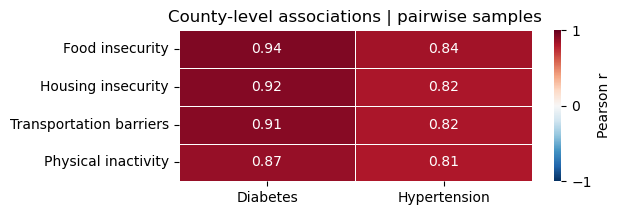

In [4]:
labels = dict(zip(shown, ["Food insecurity", "Housing insecurity",
                          "Transportation barriers", "Physical inactivity"]))
fig, ax = plt.subplots(figsize=(6.4, 2.25))
sns.heatmap(r.loc[shown].rename(index=labels, columns=dict(zip(TARGETS, ["Diabetes", "Hypertension"]))),
            annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax,
            linewidths=0.6, cbar_kws={"label": "Pearson r", "ticks": [-1, 0, 1]})
ax.set(xlabel="", ylabel="", title="County-level associations | pairwise samples")
ax.tick_params(axis="y", labelrotation=0)
fig.tight_layout()
fig.savefig(OUT / "fig_correlations.png", dpi=220, bbox_inches="tight")
plt.show()

### 4. Cluster the same 16 features used in the full notebook

Clustering includes both outcomes and factors with mean absolute correlation ≥0.40. Tier summaries are unweighted county means: disease prevalence in percent and SVI on a 0–1 scale, not national prevalence estimates. K=4 retains the project’s descriptive four-profile convention despite substantial overlap.

In [5]:
# Select by average |r| across both outcomes, then scale unequal measurement units.
strength = r.abs().mean(axis=1).sort_values(ascending=False)
features = TARGETS + strength[strength >= 0.40].index.tolist()
complete = counties.dropna(subset=features).copy()
z = preprocessing.StandardScaler().fit_transform(complete[features])
model = cluster.KMeans(n_clusters=4, random_state=42, n_init=10).fit(z)
# Label by disease/SVI anchors; inverse correlates are not positive risk contributions.
anchors = [features.index(f) for f in [*TARGETS, "RPL_THEMES"]]
order = np.argsort(model.cluster_centers_[:, anchors].mean(axis=1))
tiers = ["Low", "Moderate", "High", "Critical"]
complete["tier"] = pd.Categorical(pd.Series(model.labels_, index=complete.index)
                                  .map(dict(zip(order, tiers))), categories=tiers, ordered=True)
summary = complete.groupby("tier", observed=True).agg(
    counties=("DIABETES", "size"), diabetes=("DIABETES", "mean"),
    hypertension=("BPHIGH", "mean"), SVI=("RPL_THEMES", "mean"))
print(f"{len(features)} features; {len(complete):,}/{len(counties):,} counties retained; "
      f"{len(counties) - len(complete):,} excluded ({1 - len(complete)/len(counties):.1%}).")
print(f"K=4 silhouette: {metrics.silhouette_score(z, model.labels_):.3f} "
      "(descriptive granularity; not evidence that four groups are optimal).")
print(summary.round(3).to_string())
summary.to_csv(OUT / "cluster_summary.csv")

16 features; 2,299/2,956 counties retained; 657 excluded (22.2%).
K=4 silhouette: 0.203 (descriptive granularity; not evidence that four groups are optimal).
          counties  diabetes  hypertension    SVI
tier                                             
Low            765     9.090        29.758  0.190
Moderate       788    10.765        33.306  0.456
High           508    12.555        36.755  0.754
Critical       238    15.786        42.943  0.895


### 5. Static map: use all clustered counties for fitting, show the contiguous U.S.

Grey means no matched tier. The cached boundary file uses older county identifiers, so some current counties cannot be drawn. Compound polygon paths preserve islands and interior holes.

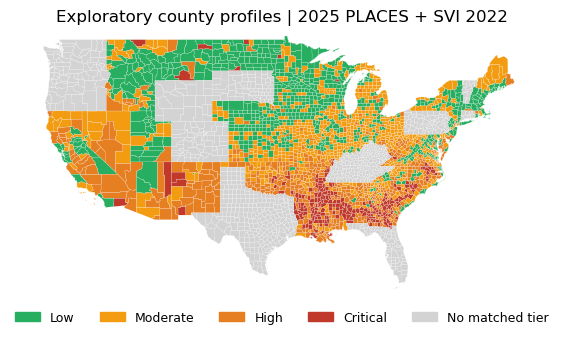

9 clustered contiguous-U.S. counties lack matching cached geometry.


In [6]:
colors = dict(zip(tiers, ["#27ae60", "#f39c12", "#e67e22", "#c0392b"]))
colors["No matched tier"] = "#d3d3d3"
lookup = complete.tier.astype("string").map(colors).to_dict()
geo = json.loads((ROOT / "processed_data/us_counties.geojson").read_text())
fig, ax = plt.subplots(figsize=(7.0, 3.5))
geometry_ids = set()
for county in geo["features"]:
    fips, geometry = county["id"], county["geometry"]
    if fips[:2] in {"02", "15", "72"}:  # Exclude Alaska, Hawaii, and Puerto Rico from this view.
        continue
    geometry_ids.add(fips)
    polygons = [geometry["coordinates"]] if geometry["type"] == "Polygon" else geometry["coordinates"]
    for polygon in polygons:
        outline = path.Path.make_compound_path(*(path.Path(ring, closed=True) for ring in polygon))
        ax.add_patch(patches.PathPatch(outline, facecolor=lookup.get(fips, colors["No matched tier"]),
                                       edgecolor="white", linewidth=0.12))
ax.set(xlim=(-125, -66), ylim=(24, 50), aspect=1.25,
       title="Exploratory county profiles | 2025 PLACES + SVI 2022")
ax.axis("off")
ax.legend(handles=[patches.Patch(color=color, label=tier) for tier, color in colors.items()],
          loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=5, fontsize=9, frameon=False)
fig.tight_layout()
fig.savefig(OUT / "fig_risk_tier_map.png", dpi=220, bbox_inches="tight")
plt.show()
unmapped = [f for f in complete.index if f[:2] not in {"02", "15", "72"} and f not in geometry_ids]
print(f"{len(unmapped)} clustered contiguous-U.S. counties lack matching cached geometry.")

**Findings and limits**

Food, housing, and transportation insecurity have the strongest disease associations.  
Physical inactivity's association changes when compared on the common county sample.  
Highest-burden profiles concentrate in the Deep South; tiers are descriptive, not clinical.  
Associations are not causal; PLACES measurement years differ (2022/2023), with SVI 2022.  
Complete cases exclude 657 counties across nine states; cached boundaries also limit coverage.